# Protein selection via supervised learning (RF and EPS), proof of concept

Using supervised to select protien

Based on methods described in [Using Supervised Learning Methods for Gene Selection in RNA-Seq Case-Control Studies](https://www.frontiersin.org/journals/genetics/articles/10.3389/fgene.2018.00297/full?ref=https://githubhelp.com)

The two methods are 
- Random Forests (RF) — permutation importance ranking
- Extreme Pseudo-Samples (EPS) — VAE + linear regression ranking (VAE + Elastic Net)

## Imports

In [26]:
import sys
sys.path.append("..")

import itertools
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests

# SKlearn imports
import sklearn
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.core.data_utils import get_protein_features

## Load data and pre-filter (for proof of concept)

- Load your seen/unseen datasets (proteins as columns, patients as rows)
- Remove proteins with near-zero variance (threshold e.g. variance < 0.01)
- Aim to reduce from 11,000 to ~2,000–3,000 proteins
- Keep the same filtered protein set for both seen and unseen

In [3]:
seen_df = pd.read_csv("../data/processed/seen.csv")
unseen_df = pd.read_csv("../data/processed/unseen.csv")

protein_cols = np.array(get_protein_features(seen_df))
X_seen = seen_df[protein_cols].values
y_seen = seen_df["ards"].values

X_unseen = unseen_df[protein_cols].values
y_unseen = unseen_df["ards"].values

print("Seen data shape:", X_seen.shape)
print("Unseen data shape:", X_unseen.shape)

Seen data shape: (326, 10776)
Unseen data shape: (82, 10776)


In [4]:
n_ards_seen = np.sum(y_seen)
n_sepsis_seen = len(y_seen) - n_ards_seen
n_ards_unseen = np.sum(y_unseen)
n_sepsis_unseen = len(y_unseen) - n_ards_unseen

print(f"Seen data: {n_ards_seen} ARDS samples, {n_sepsis_seen} sepsis samples")
print(f"Unseen data: {n_ards_unseen} ARDS samples, {n_sepsis_unseen} sepsis samples")

Seen data: 52 ARDS samples, 274 sepsis samples
Unseen data: 13 ARDS samples, 69 sepsis samples


In [5]:
selected_mask = np.ones(len(protein_cols), dtype=bool)
thrs = 0.01
while np.sum(selected_mask) < 2000 or np.sum(selected_mask) > 3000:

    vt_selector = VarianceThreshold(threshold=thrs)
    vt_selector.fit(X_seen)

    selected_mask = vt_selector.get_support(indices=False)
    if np.sum(selected_mask) < 2000:
        thrs *= 0.9
    elif np.sum(selected_mask) > 3000:
        thrs *= 1.1

protein_cols_filt = protein_cols[selected_mask]

X_seen_filt = X_seen[:, selected_mask]
X_unseen_filt = X_unseen[:, selected_mask]

print("Selected protein features:", protein_cols_filt)
print("Number of selected features:", len(protein_cols_filt))

Selected protein features: ['seq.10014.31' 'seq.10025.1' 'seq.10037.98' ... 'seq.9991.112'
 'seq.9995.6' 'seq.9997.12']
Number of selected features: 2744


## Baseline (t-tests)

In [6]:
X_seen_filt[0:2,4]

array([3.6339328 , 4.42178813])

In [7]:
pvals = []
mask1 = (y_seen == 1)   # ARDS
mask0 = (y_seen == 0)   # non-ARDS

for prot in range(X_seen_filt.shape[1]):
    g1 = X_seen_filt[mask1, prot]
    g0 = X_seen_filt[mask0, prot]

    mean_diff = g1.mean() - g0.mean()

    t = stats.ttest_ind(
        g1, g0,
        equal_var=False
    )
    pval = float(t.pvalue)
    pvals.append(pval)

# Adjust p-values for multiple testing
_, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')

In [8]:
# store top proteins in dict {k: [top_1, top_2, ..., top_k]} based on importance_mean
top_proteins_ttest_dict = {}
top_proteins_pvals_adj = {}
for k in np.linspace(1, 50, 50, dtype=int):
    top_indices = np.argsort(pvals_adj)[:k]
    top_proteins_ttest_dict[k] = protein_cols_filt[top_indices].tolist()
    top_proteins_pvals_adj[k] = pvals_adj[top_indices]

print(f"Top 20 proteins by importance: {top_proteins_ttest_dict[20]:}")
print(f"Top 20 proteins ajdusted p-vals: {top_proteins_pvals_adj[20]}")

Top 20 proteins by importance: ['seq.18205.123', 'seq.17813.21', 'seq.22528.1', 'seq.25094.9', 'seq.31183.95', 'seq.12351.25', 'seq.17768.50', 'seq.17792.158', 'seq.31598.17', 'seq.24646.47', 'seq.25484.120', 'seq.15566.10', 'seq.21781.9', 'seq.23178.95', 'seq.10370.21', 'seq.27155.9', 'seq.5852.6', 'seq.6557.50', 'seq.20054.28', 'seq.19120.33']
Top 20 proteins ajdusted p-vals: [0.00045189 0.00288038 0.00317492 0.00888613 0.00991616 0.00991616
 0.01323127 0.01323127 0.01323127 0.01323127 0.01457091 0.02546915
 0.02546915 0.02546915 0.02546915 0.02551992 0.02551992 0.02792181
 0.02801306 0.03674634]


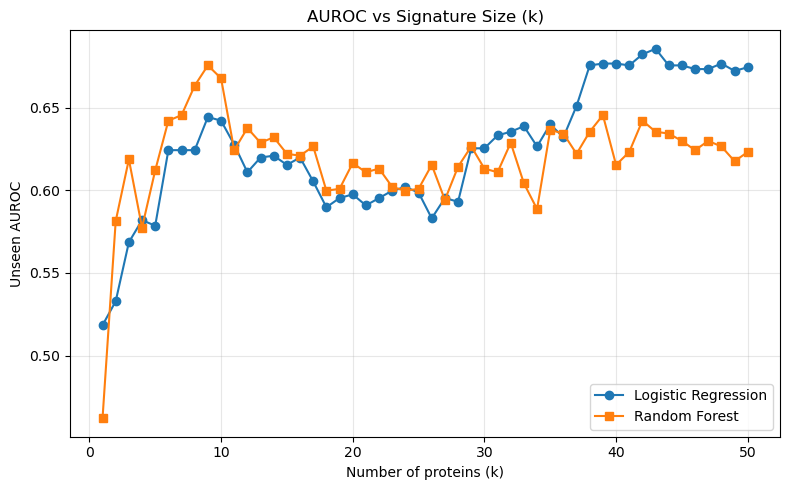

In [9]:
lr_classif = LogisticRegression(class_weight="balanced", max_iter=1000)
rf_classif = RandomForestClassifier(n_estimators=500, max_features='sqrt', max_depth=5, class_weight='balanced', n_jobs=-1, random_state=42)

k_values = []
auroc_values_ttest_lr = []
auroc_values_ttest_rf = []

for k in sorted(top_proteins_ttest_dict.keys()):
    top_proteins = top_proteins_ttest_dict[k]
    top_indices = [np.where(protein_cols_filt == p)[0][0] for p in top_proteins]

    # Use filtered matrices, since top_indices refer to protein_cols_filt
    X_seen_top = X_seen_filt[:, top_indices]
    X_unseen_top = X_unseen_filt[:, top_indices]

    lr_classif.fit(X_seen_top, y_seen)
    y_unseen_proba = lr_classif.predict_proba(X_unseen_top)[:, 1]
    auroc = roc_auc_score(y_unseen, y_unseen_proba)

    k_values.append(int(k))
    auroc_values_ttest_lr.append(auroc)
    #print(f"Top {int(k)} proteins - Unseen AUROC: {auroc:.4f}")

    rf_classif.fit(X_seen_top, y_seen)
    y_unseen_proba_rf = rf_classif.predict_proba(X_unseen_top)[:, 1]
    auroc_rf = roc_auc_score(y_unseen, y_unseen_proba_rf)
    auroc_values_ttest_rf.append(auroc_rf)

plt.figure(figsize=(8, 5))
plt.plot(k_values, auroc_values_ttest_lr, marker="o", label="Logistic Regression")
plt.plot(k_values, auroc_values_ttest_rf, marker="s", label="Random Forest")
plt.xlabel("Number of proteins (k)")
plt.ylabel("Unseen AUROC")
plt.title("AUROC vs Signature Size (k)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Random forest

### Define random forest classifier

In [10]:
# Split seen data: 80% to train RF, 20% to evaluate permutation importance
X_train, X_eval, y_train, y_eval = train_test_split(
    X_seen_filt, y_seen,
    test_size=0.2,
    stratify=y_seen,   # important given class imbalance
    random_state=42
)

# Train RF on train subset only
rf_classif = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_classif.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Permutation importance

Can also use Gini importance alongside permutation importance

In [11]:
# Compute permutation importance on eval subset
perm_results = permutation_importance(
    rf_classif, X_eval, y_eval,
    scoring="roc_auc",
    n_repeats=10,
    n_jobs=-1,
    random_state=42
)

### Generate signatures

In [12]:
# store top proteins in dict {k: [top_1, top_2, ..., top_k]} based on importance_mean
top_proteins_rf_dict = {}
top_proteins_importance = {}
for k in np.linspace(1, 50, 50, dtype=int):
    top_indices = np.argsort(perm_results.importances_mean, )[::-1][:k]
    top_proteins_rf_dict[k] = protein_cols_filt[top_indices].tolist()
    top_proteins_importance[k] = perm_results.importances_mean[top_indices]

print(f"Top 20 proteins by importance: {top_proteins_rf_dict[20]:}")
print(f"Top 20 proteins importance: {top_proteins_importance[20]}")

Top 20 proteins by importance: ['seq.18233.10', 'seq.23903.3', 'seq.18188.12', 'seq.30373.68', 'seq.6518.85', 'seq.21240.6', 'seq.24211.25', 'seq.18271.43', 'seq.25049.8', 'seq.18338.26', 'seq.21552.9', 'seq.24943.117', 'seq.18185.118', 'seq.14636.25', 'seq.18343.10', 'seq.26045.1', 'seq.4125.52', 'seq.17456.53', 'seq.19241.31', 'seq.11516.7']
Top 20 proteins importance: [0.00958678 0.00892562 0.00867769 0.00826446 0.00752066 0.00636364
 0.00561983 0.00553719 0.0053719  0.00504132 0.00487603 0.00479339
 0.00438017 0.00438017 0.00429752 0.00421488 0.00413223 0.00413223
 0.00413223 0.00404959]


### Cross-reference against known pathway database (for future)

### Evaluate on unseen data

For each signature size k:
- Train a simple logistic regression on seen data using only those k proteins
- Predict on unseen data
- Record AUROC

Plot AUROC vs. k

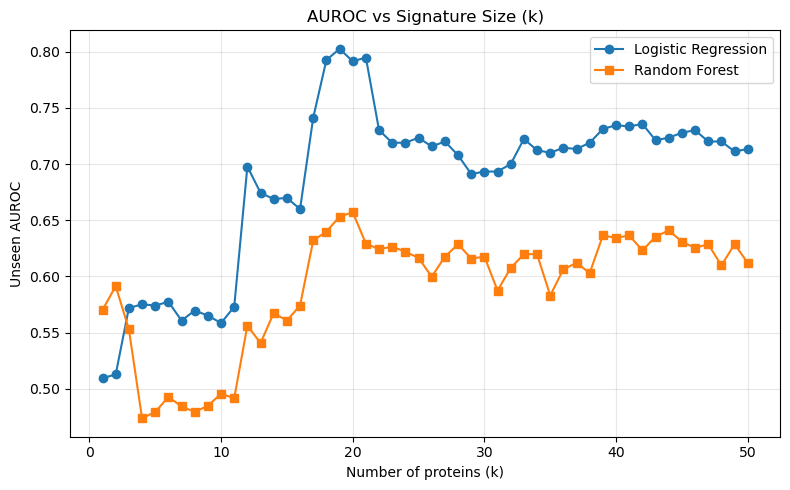

In [13]:
lr_classif = LogisticRegression(class_weight="balanced", max_iter=1000)
rf_classif = RandomForestClassifier(n_estimators=500, max_features='sqrt', max_depth=5, class_weight='balanced', n_jobs=-1, random_state=42)

k_values = []
auroc_values_rf_lr = []
auroc_values_rf_rf = []

for k in sorted(top_proteins_rf_dict.keys()):
    top_proteins = top_proteins_rf_dict[k]
    top_indices = [np.where(protein_cols_filt == p)[0][0] for p in top_proteins]

    # Use filtered matrices, since top_indices refer to protein_cols_filt
    X_seen_top = X_seen_filt[:, top_indices]
    X_unseen_top = X_unseen_filt[:, top_indices]

    lr_classif.fit(X_seen_top, y_seen)
    y_unseen_proba = lr_classif.predict_proba(X_unseen_top)[:, 1]
    auroc = roc_auc_score(y_unseen, y_unseen_proba)

    k_values.append(int(k))
    auroc_values_rf_lr.append(auroc)
    #print(f"Top {int(k)} proteins - Unseen AUROC: {auroc:.4f}")

    rf_classif.fit(X_seen_top, y_seen)
    y_unseen_proba_rf = rf_classif.predict_proba(X_unseen_top)[:, 1]
    auroc_rf = roc_auc_score(y_unseen, y_unseen_proba_rf)
    auroc_values_rf_rf.append(auroc_rf)

plt.figure(figsize=(8, 5))
plt.plot(k_values, auroc_values_rf_lr, marker="o", label="Logistic Regression")
plt.plot(k_values, auroc_values_rf_rf, marker="s", label="Random Forest")
plt.xlabel("Number of proteins (k)")
plt.ylabel("Unseen AUROC")
plt.title("AUROC vs Signature Size (k)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## EPS (Extreme Pseudo Sampling)

### Standardise features

Standardise features on seen (filtered) data using a StandardScaler

In [14]:
scaler = StandardScaler()
X_seen_scaled = scaler.fit_transform(X_seen_filt)
X_unseen_scaled = scaler.transform(X_unseen_filt)

print("Seen scaled shape:", X_seen_scaled.shape)
print("Mean (seen, first 5 features):", X_seen_scaled.mean(axis=0)[:5])
print("Std  (seen, first 5 features):", X_seen_scaled.std(axis=0)[:5])

Seen scaled shape: (326, 2744)
Mean (seen, first 5 features): [-2.72447368e-16 -9.64463683e-16 -5.66690525e-16 -1.29684947e-15
  2.66998421e-15]
Std  (seen, first 5 features): [1. 1. 1. 1. 1.]


### Train lightweight VAE (Variation Autoencoder) on seen data

Architecture (PoC scale, CPU-friendly):

- `Input (2000) → FC(512) → ReLU → FC(128) → [μ, logσ²]  # Encoder`
- `z (32-dim latent) → FC(128) → ReLU → FC(512) → ReLU → FC(2000)  # Decoder`

Loss = reconstruction loss (MSE) + KL divergence

Train for ~50–100 epochs, batch size 32

The paper used a massive 9-layer network — unnecessary for PoC

Epoch  10/100  loss: 0.0359
Epoch  20/100  loss: 0.0359
Epoch  30/100  loss: 0.0342
Epoch  40/100  loss: 0.0332
Epoch  50/100  loss: 0.0324
Epoch  60/100  loss: 0.0329
Epoch  70/100  loss: 0.0325
Epoch  80/100  loss: 0.0302
Epoch  90/100  loss: 0.0307
Epoch 100/100  loss: 0.0317


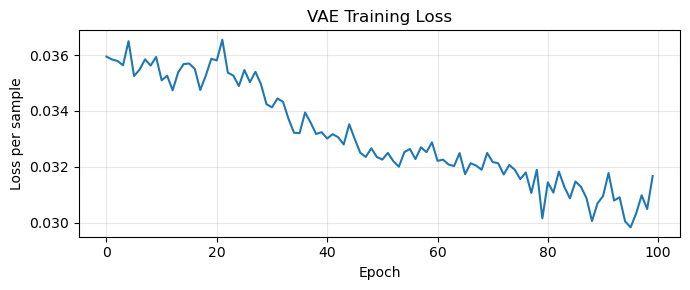

In [82]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1=512, hidden2=128, latent_dim=32):
        super().__init__()
        # Encoder
        self.enc1 = nn.Linear(input_dim, hidden1)
        self.enc2 = nn.Linear(hidden1, hidden2)
        self.fc_mu     = nn.Linear(hidden2, latent_dim)
        self.fc_logvar = nn.Linear(hidden2, latent_dim)
        # Decoder
        self.dec1 = nn.Linear(latent_dim, hidden2)
        self.dec2 = nn.Linear(hidden2, hidden1)
        self.dec_out = nn.Linear(hidden1, input_dim)
        # Classifier head on latent space
        self.classifier = nn.Linear(latent_dim, 1)

    def encode(self, x):
        h = torch.relu(self.enc1(x))
        h = torch.relu(self.enc2(h))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        h = torch.relu(self.dec1(z))
        h = torch.relu(self.dec2(h))
        return self.dec_out(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        x_recon = self.decode(z)
        y_logit = self.classifier(mu)  # classify from mu, not z
        return x_recon, mu, logvar, y_logit

def vae_loss(x_recon, x, mu, logvar, y_logit, y_true, beta=1.5, gamma=0.05):
    recon = nn.functional.mse_loss(x_recon, x, reduction='mean')
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Weighted BCE to handle 52 ARDS vs 274 sepsis imbalance
    pos_weight = torch.tensor([n_sepsis_seen / n_ards_seen])
    clf_loss = nn.functional.binary_cross_entropy_with_logits(
        y_logit.squeeze(), y_true.float(), pos_weight=pos_weight
    )
    return recon + beta * kl + gamma * clf_loss


# --- Training ---
# random seed
torch.manual_seed(42)

input_dim  = X_seen_scaled.shape[1]
n_epochs   = 100
batch_size = 32

X_tensor = torch.tensor(X_seen_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_seen, dtype=torch.float32)
loader   = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=32, shuffle=True)

vae = VAE(input_dim=input_dim, hidden1=512, hidden2=128, latent_dim=32)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae.train()
train_losses = []
for epoch in range(n_epochs):
    epoch_loss = 0.0
    for (batch_x, batch_y) in loader:
        optimizer.zero_grad()
        x_recon, mu, logvar, y_logit = vae(batch_x)
        loss = vae_loss(x_recon, batch_x, mu, logvar, y_logit, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(X_tensor))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs}  loss: {train_losses[-1]:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss per sample")
plt.title("VAE Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Encode all seen samples
- Pass all seen samples through encoder → get latent vectors μ for each patient
- We now have a (n_patients × 32) matrix

In [83]:
# Encode all seen samples to latent mean vectors (mu)
vae.eval()
with torch.no_grad():
    X_seen_tensor = torch.tensor(X_seen_scaled, dtype=torch.float32)
    mu_seen, logvar_seen = vae.encode(X_seen_tensor)

Z_seen_mu = np.asarray(mu_seen.detach().cpu().tolist(), dtype=np.float32)   # shape: (n_patients, 32)

print("Latent mean matrix shape:", Z_seen_mu.shape)
print("First patient, first 5 latent dims:", Z_seen_mu[0, :5])

Latent mean matrix shape: (326, 32)
First patient, first 5 latent dims: [-0.33726195 -0.01858762 -0.16835521 -0.00707297  0.11381772]


c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


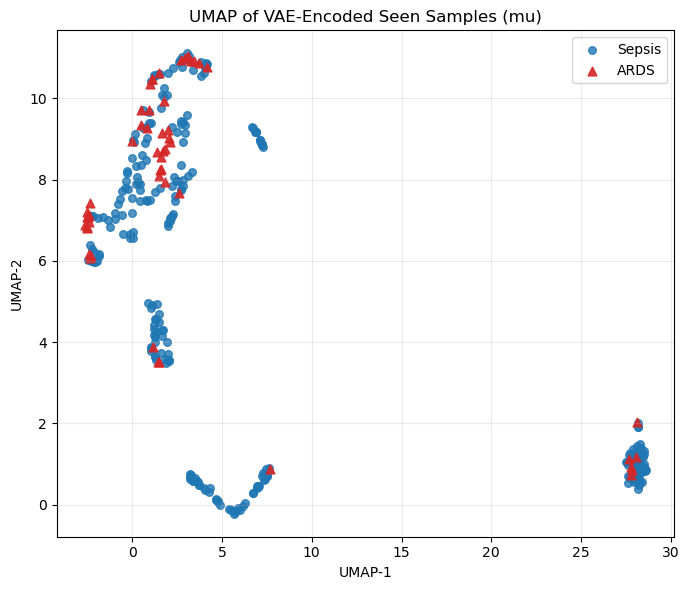

In [84]:
try:
    import umap.umap_ as umap
except ImportError:
    raise ImportError(
        "umap-learn is not installed. Install it with: pip install umap-learn"
    )

import matplotlib.pyplot as plt
import numpy as np

# Z_seen_mu: (n_patients, latent_dim), y_seen: 0/1 labels
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)
Z_umap = reducer.fit_transform(Z_seen_mu)

plt.figure(figsize=(7, 6))
mask_sepsis = (y_seen == 0)
mask_ards = (y_seen == 1)

plt.scatter(
    Z_umap[mask_sepsis, 0], Z_umap[mask_sepsis, 1],
    s=30, alpha=0.8, c="#1f77b4", label="Sepsis"
)
plt.scatter(
    Z_umap[mask_ards, 0], Z_umap[mask_ards, 1],
    s=40, alpha=0.9, c="#d62728", marker="^", label="ARDS"
)

plt.title("UMAP of VAE-Encoded Seen Samples (mu)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [85]:
# Check within-class spread in latent space
Z_ards = Z_seen_mu[mask_ards]
Z_sepsis = Z_seen_mu[mask_sepsis]

print("ARDS latent std (mean across dims):", Z_ards.std(axis=0).mean())
print("Sepsis latent std (mean across dims):", Z_sepsis.std(axis=0).mean())
print("Between-class centroid distance:", 
      np.linalg.norm(Z_ards.mean(axis=0) - Z_sepsis.mean(axis=0)))

ARDS latent std (mean across dims): 0.21712577
Sepsis latent std (mean across dims): 0.23978561
Between-class centroid distance: 0.95817626


### Find linear separator in latent space

- Train a LinearSVC or logistic regression on the latent vectors (ARDS vs Sepsis)
- Verify separation quality — we should get high accuracy here; if not, increase latent dim or epochs

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score

# Latent features from previous step
X_latent = Z_seen_mu
y_latent = y_seen.astype(int)

# Stratified split for honest separation check
X_tr, X_te, y_tr, y_te = train_test_split(
    X_latent, y_latent,
    test_size=0.25,
    stratify=y_latent,
    random_state=42
)

# 1) Logistic regression in latent space
lr_latent = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)
lr_latent.fit(X_tr, y_tr)

lr_pred = lr_latent.predict(X_te)
lr_proba = lr_latent.predict_proba(X_te)[:, 1]
lr_acc = (lr_pred == y_te).mean()
lr_auroc = roc_auc_score(y_te, lr_proba)

# 2) Linear SVC in latent space
svc_latent = LinearSVC(
    class_weight="balanced",
    max_iter=10000,
    random_state=42
)
svc_latent.fit(X_tr, y_tr)

svc_pred = svc_latent.predict(X_te)
svc_score = svc_latent.decision_function(X_te)
svc_acc = (svc_pred == y_te).mean()
svc_auroc = roc_auc_score(y_te, svc_score)

print(f"LogReg latent ACC   : {lr_acc:.3f}")
print(f"LogReg latent AUROC : {lr_auroc:.3f}")
print(f"LinSVC latent ACC   : {svc_acc:.3f}")
print(f"LinSVC latent AUROC : {svc_auroc:.3f}")

LogReg latent ACC   : 0.793
LogReg latent AUROC : 0.862
LinSVC latent ACC   : 0.793
LinSVC latent AUROC : 0.858


### Identify extreme regions and sample

- Project all latent points onto the decision boundary normal vector
- For each class, find the points furthest from the boundary (top 10% by projection distance)
- These are your "extreme" regions Nc and Cc
- Sample 200 random points in each extreme region (400 total). Practical approach: take the extreme real latent points, add small Gaussian noise to generate neighbours

In [87]:
# Use a trained linear separator from previous cell (prefer SVC, fallback to LR)
clf_full = LinearSVC(class_weight="balanced", max_iter=10000, random_state=42)
clf_full.fit(Z_seen_mu, y_seen) 

w = clf_full.coef_.ravel().astype(np.float64)          # normal vector
b = float(clf_full.intercept_.ravel()[0])              # intercept
w_norm = np.linalg.norm(w) + 1e-12

# Signed distance to decision boundary: positive -> ARDS side, negative -> Sepsis side
signed_dist = (Z_seen_mu @ w + b) / w_norm

# Class masks
mask_ards = (y_seen == 1)
mask_sepsis = (y_seen == 0)

# Top 15% farthest per class from boundary (class-specific direction)
q = 0.85
thr_ards = np.quantile(signed_dist[mask_ards], q)      # large positive
thr_sepsis = np.quantile(-signed_dist[mask_sepsis], q) # large negative in original sign

idx_ards_ext = np.where(mask_ards & (signed_dist >= thr_ards))[0]     # Cc
idx_sepsis_ext = np.where(mask_sepsis & (signed_dist <= -thr_sepsis))[0]  # Nc

Z_ards_ext = Z_seen_mu[idx_ards_ext]
Z_sepsis_ext = Z_seen_mu[idx_sepsis_ext]

print("Extreme ARDS points (Cc):", len(Z_ards_ext))
print("Extreme Sepsis points (Nc):", len(Z_sepsis_ext))

# Sample pseudo-points by adding small Gaussian noise around extreme real points
rng = np.random.default_rng(42)
n_per_class = 200
noise_scale = 0.15  

latent_std = Z_seen_mu.std(axis=0, ddof=1)
sigma = noise_scale * np.where(latent_std > 0, latent_std, 1.0)

def sample_pseudos(Z_extreme, n_samples, sigma_vec, rng):
    base_idx = rng.integers(0, len(Z_extreme), size=n_samples)
    base = Z_extreme[base_idx]
    noise = rng.normal(loc=0.0, scale=sigma_vec, size=base.shape)
    return base + noise

Z_ards_pseudo = sample_pseudos(Z_ards_ext, n_per_class, sigma, rng)
Z_sepsis_pseudo = sample_pseudos(Z_sepsis_ext, n_per_class, sigma, rng)

# Combined pseudo latent dataset (400 total)
Z_pseudo = np.vstack([Z_sepsis_pseudo, Z_ards_pseudo]).astype(np.float32)
y_pseudo = np.hstack([
    np.zeros(n_per_class, dtype=int),
    np.ones(n_per_class, dtype=int)
])

print("Pseudo latent set shape:", Z_pseudo.shape)
print("Pseudo labels shape:", y_pseudo.shape)
print("Class counts:", np.bincount(y_pseudo))

Extreme ARDS points (Cc): 8
Extreme Sepsis points (Nc): 41
Pseudo latent set shape: (400, 32)
Pseudo labels shape: (400,)
Class counts: [200 200]


### Decode pseudo-samples

- Pass the 400 latent points through the decoder
- You now have 400 pseudo-samples in protein expression space (200 per class)
- These should be linearly separable — verify with a quick logistic regression

In [88]:
# Decode pseudo latent points -> pseudo protein-expression samples (in scaled feature space)
vae.eval()
with torch.no_grad():
    Z_pseudo_tensor = torch.tensor(Z_pseudo, dtype=torch.float32)
    X_pseudo_scaled_t = vae.decode(Z_pseudo_tensor)

# Avoid tensor.numpy() bridge (fails in your environment)
X_pseudo_scaled = np.asarray(X_pseudo_scaled_t.detach().cpu().tolist(), dtype=np.float32)

print("Decoded pseudo-samples (scaled space):", X_pseudo_scaled.shape)
print("Pseudo labels:", y_pseudo.shape, "class counts:", np.bincount(y_pseudo))

# Optional: back-transform to original protein scale for inspection/export
X_pseudo = scaler.inverse_transform(X_pseudo_scaled)
print("Decoded pseudo-samples (original scale):", X_pseudo.shape)

# Quick linear separability check with logistic regression
Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(
    X_pseudo_scaled, y_pseudo,
    test_size=0.25,
    stratify=y_pseudo,
    random_state=42
)

lr_pseudo = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)
lr_pseudo.fit(Xtr_p, ytr_p)

yhat_p = lr_pseudo.predict(Xte_p)
yproba_p = lr_pseudo.predict_proba(Xte_p)[:, 1]

acc_p = (yhat_p == yte_p).mean()
auroc_p = roc_auc_score(yte_p, yproba_p)

print(f"Pseudo-set LogReg ACC   : {acc_p:.3f}")
print(f"Pseudo-set LogReg AUROC : {auroc_p:.3f}")

Decoded pseudo-samples (scaled space): (400, 2744)
Pseudo labels: (400,) class counts: [200 200]
Decoded pseudo-samples (original scale): (400, 2744)
Pseudo-set LogReg ACC   : 1.000
Pseudo-set LogReg AUROC : 1.000


###  Fit elastic net on pseudo-samples and generate signatures

- ElasticNet or LogisticRegressionCV(penalty='elasticnet', l1_ratio=0.5)
- Fit on the 400 pseudo-samples
- Extract coefficients → sort by absolute value → protein ranking
- The λ is selected by CV on pseudo-samples
- Generate signatures

In [89]:
from sklearn.linear_model import LinearRegression

# OLS on pseudo-samples (no regularization)
# y is binary (0/1), but we fit a plain linear model as in EPS-style coefficient ranking
ols = LinearRegression(fit_intercept=True)
ols.fit(X_pseudo_scaled, y_pseudo.astype(float))

coef = np.asarray(ols.coef_).ravel()

# Rank proteins by absolute OLS coefficient
ranking_df = pd.DataFrame({
    "protein": protein_cols_filt,
    "coef": coef,
    "abs_coef": np.abs(coef),
    "direction": np.where(coef >= 0, "ARDS", "Sepsis")
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

# With OLS and continuous coefficients, this is usually close to all features
nnz = int(np.sum(np.abs(coef) > 1e-12))
print(f"Non-zero coefficients: {nnz} / {len(ranking_df)}")
print("\nTop 20 proteins by |OLS coef|:")
display(ranking_df.head(20))

# Top-k signatures for EPS evaluation (k = 1..50)
top_proteins_eps_dict = {
    k: ranking_df.loc[:k-1, "protein"].tolist()
    for k in range(1, 51)
}

Non-zero coefficients: 2744 / 2744

Top 20 proteins by |OLS coef|:


,protein,coef,abs_coef,direction
0,seq.8232.90,-0.258797,0.258797,Sepsis
1,seq.2748.3,0.199300,0.199300,ARDS
2,seq.12551.3,-0.198374,0.198374,Sepsis
3,seq.12340.17,-0.196295,0.196295,Sepsis
4,seq.13431.74,-0.187685,0.187685,Sepsis
5,seq.29199.21,-0.186270,0.186270,Sepsis
6,seq.8465.52,0.182837,0.182837,ARDS
7,seq.8076.4,-0.182636,0.182636,Sepsis
8,seq.3714.49,0.178719,0.178719,ARDS
9,seq.7096.30,0.178300,0.178300,ARDS


### Evaluate

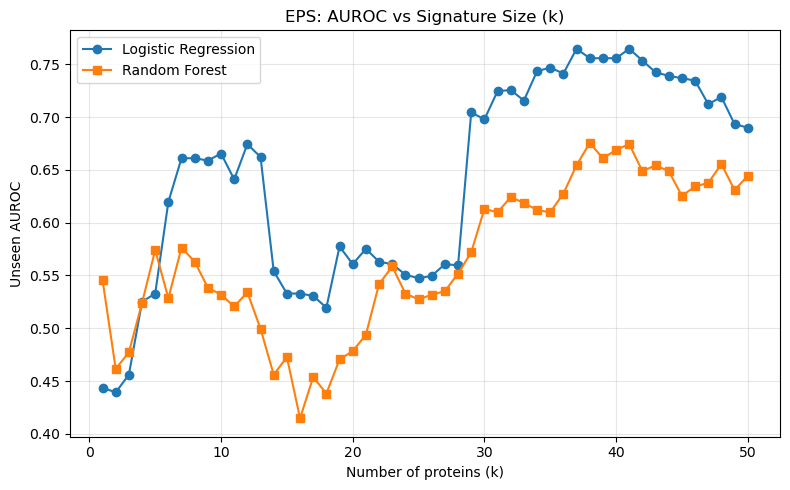

In [90]:
# Evaluate EPS-ranked proteins on unseen data (same protocol as RF block)
lr_classif = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
rf_classif = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    max_depth=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

k_values_eps = []
auroc_values_eps_lr = []
auroc_values_eps_rf = []

for k in sorted(top_proteins_eps_dict.keys()):
    top_proteins = top_proteins_eps_dict[k]
    top_indices = [np.where(protein_cols_filt == p)[0][0] for p in top_proteins]

    X_seen_top = X_seen_filt[:, top_indices]
    X_unseen_top = X_unseen_filt[:, top_indices]

    # LR on seen, evaluate on unseen
    lr_classif.fit(X_seen_top, y_seen)
    y_unseen_proba_lr = lr_classif.predict_proba(X_unseen_top)[:, 1]
    auroc_lr = roc_auc_score(y_unseen, y_unseen_proba_lr)

    # RF on seen, evaluate on unseen
    rf_classif.fit(X_seen_top, y_seen)
    y_unseen_proba_rf = rf_classif.predict_proba(X_unseen_top)[:, 1]
    auroc_rf = roc_auc_score(y_unseen, y_unseen_proba_rf)

    k_values_eps.append(int(k))
    auroc_values_eps_lr.append(auroc_lr)
    auroc_values_eps_rf.append(auroc_rf)

plt.figure(figsize=(8, 5))
plt.plot(k_values_eps, auroc_values_eps_lr, marker="o", label="Logistic Regression")
plt.plot(k_values_eps, auroc_values_eps_rf, marker="s", label="Random Forest")
plt.xlabel("Number of proteins (k)")
plt.ylabel("Unseen AUROC")
plt.title("EPS: AUROC vs Signature Size (k)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Final comparison

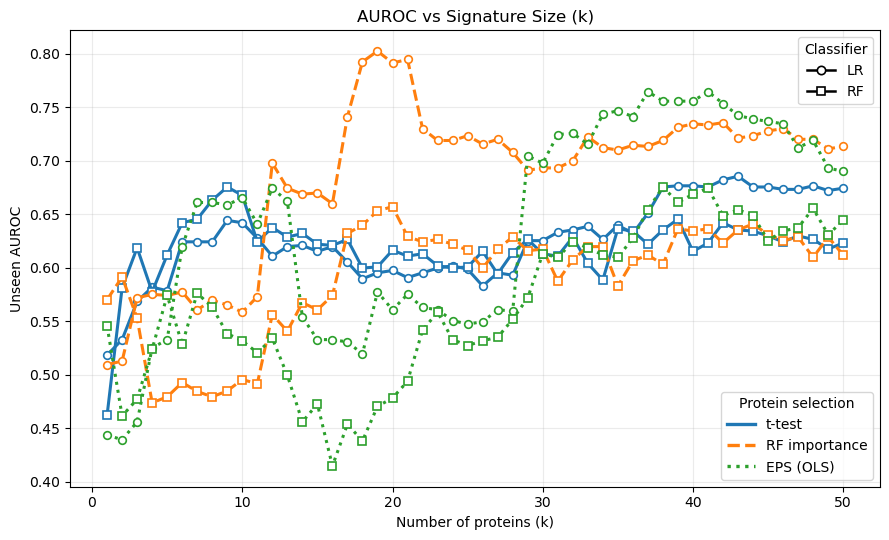

In [91]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9, 5.5))

# Style maps
method_style = {
    "t-test": {"color": "#1f77b4", "linestyle": "-"},
    "RF importance": {"color": "#ff7f0e", "linestyle": "--"},
    "EPS (OLS)": {"color": "#2ca02c", "linestyle": ":"},
}
clf_style = {
    "LR": {"marker": "o"},
    "RF": {"marker": "s"},
}

# Plot all curves with dual encoding
ax.plot(
    k_values, auroc_values_ttest_lr,
    color=method_style["t-test"]["color"],
    linestyle=method_style["t-test"]["linestyle"],
    marker=clf_style["LR"]["marker"],
    linewidth=2.2, markersize=5.5, markerfacecolor="white", markeredgewidth=1.2
)
ax.plot(
    k_values, auroc_values_ttest_rf,
    color=method_style["t-test"]["color"],
    linestyle=method_style["t-test"]["linestyle"],
    marker=clf_style["RF"]["marker"],
    linewidth=2.2, markersize=5.5, markerfacecolor="white", markeredgewidth=1.2
)

ax.plot(
    k_values, auroc_values_rf_lr,
    color=method_style["RF importance"]["color"],
    linestyle=method_style["RF importance"]["linestyle"],
    marker=clf_style["LR"]["marker"],
    linewidth=2.2, markersize=5.5, markerfacecolor="white", markeredgewidth=1.2
)
ax.plot(
    k_values, auroc_values_rf_rf,
    color=method_style["RF importance"]["color"],
    linestyle=method_style["RF importance"]["linestyle"],
    marker=clf_style["RF"]["marker"],
    linewidth=2.2, markersize=5.5, markerfacecolor="white", markeredgewidth=1.2
)

ax.plot(
    k_values_eps, auroc_values_eps_lr,
    color=method_style["EPS (OLS)"]["color"],
    linestyle=method_style["EPS (OLS)"]["linestyle"],
    marker=clf_style["LR"]["marker"],
    linewidth=2.2, markersize=5.5, markerfacecolor="white", markeredgewidth=1.2
)
ax.plot(
    k_values_eps, auroc_values_eps_rf,
    color=method_style["EPS (OLS)"]["color"],
    linestyle=method_style["EPS (OLS)"]["linestyle"],
    marker=clf_style["RF"]["marker"],
    linewidth=2.2, markersize=5.5, markerfacecolor="white", markeredgewidth=1.2
)

# Axes formatting
ax.set_xlabel("Number of proteins (k)")
ax.set_ylabel("Unseen AUROC")
ax.set_title("AUROC vs Signature Size (k)")
ax.grid(True, alpha=0.25)

# Separate legends to decode each visual channel
method_handles = [
    Line2D([0], [0], color=v["color"], linestyle=v["linestyle"], linewidth=2.4, label=k)
    for k, v in method_style.items()
]
clf_handles = [
    Line2D([0], [0], color="black", linestyle="-", marker=v["marker"],
           markerfacecolor="white", markeredgewidth=1.2, linewidth=1.8, label=k)
    for k, v in clf_style.items()
]

legend_methods = ax.legend(handles=method_handles, title="Protein selection", loc="lower right")
ax.add_artist(legend_methods)
ax.legend(handles=clf_handles, title="Classifier", loc="upper right")

plt.tight_layout()
plt.show()

In [92]:
methods = {
    "EPS": top_proteins_eps_dict,
    "RF": top_proteins_rf_dict,
    "t-test": top_proteins_ttest_dict,
}

# Ensure we only use k values present in all three dicts
common_k = sorted(set.intersection(*(set(d.keys()) for d in methods.values())))
if not common_k:
    raise ValueError("No common k values across the three dictionaries.")

def sets_at_k(k):
    return {name: set(d[k]) for name, d in methods.items()}

def pairwise_metrics(sets_dict):
    rows = []
    names = list(sets_dict.keys())
    for a, b in itertools.combinations(names, 2):
        A, B = sets_dict[a], sets_dict[b]
        inter = len(A & B)
        union = len(A | B)
        jacc = inter / union if union else np.nan
        overlap_coef = inter / min(len(A), len(B)) if min(len(A), len(B)) else np.nan
        rows.append({
            "pair": f"{a} vs {b}",
            "intersection_n": inter,
            "union_n": union,
            "jaccard": jacc,
            "overlap_coef": overlap_coef,
        })
    return pd.DataFrame(rows)

def region_counts_3way(sets_dict):
    A, B, C = sets_dict["EPS"], sets_dict["RF"], sets_dict["t-test"]
    abc = len(A & B & C)
    ab_only = len((A & B) - C)
    ac_only = len((A & C) - B)
    bc_only = len((B & C) - A)
    a_only = len(A - (B | C))
    b_only = len(B - (A | C))
    c_only = len(C - (A | B))
    return pd.DataFrame({
        "region": ["EPS only", "RF only", "t-test only", "EPS∩RF only", "EPS∩t-test only", "RF∩t-test only", "All three"],
        "count": [a_only, b_only, c_only, ab_only, ac_only, bc_only, abc]
    })

def overlap_report(k):
    S = sets_at_k(k)
    size_df = pd.DataFrame({
        "method": list(S.keys()),
        "set_size": [len(v) for v in S.values()]
    })
    pair_df = pairwise_metrics(S)
    region_df = region_counts_3way(S)

    all_three = len(S["EPS"] & S["RF"] & S["t-test"])
    union_all = len(S["EPS"] | S["RF"] | S["t-test"])
    all_three_vs_union = all_three / union_all if union_all else np.nan

    print(f"Overlap report for k={k}")
    print(f"All three overlap: {all_three} proteins")
    print(f"All three / union: {all_three_vs_union:.3f}")

    display(size_df)
    display(pair_df.sort_values("jaccard", ascending=False))
    display(region_df.sort_values("count", ascending=False))

    return size_df, pair_df, region_df

Overlap report for k=50
All three overlap: 0 proteins
All three / union: 0.000


,method,set_size
0,EPS,50
1,RF,50
2,t-test,50


,pair,intersection_n,union_n,jaccard,overlap_coef
2,RF vs t-test,4,96,0.041667,0.08
0,EPS vs RF,0,100,0.000000,0.00
1,EPS vs t-test,0,100,0.000000,0.00


,region,count
0,EPS only,50
1,RF only,46
2,t-test only,46
5,RF∩t-test only,4
3,EPS∩RF only,0
4,EPS∩t-test only,0
6,All three,0


C:\Users\Love\AppData\Local\Temp\ipykernel_5796\16411522.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=size_df, x="method", y="set_size", ax=axes[0], palette="Set2")
C:\Users\Love\AppData\Local\Temp\ipykernel_5796\16411522.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_df, x="region", y="count", ax=axes[2], palette="tab10")


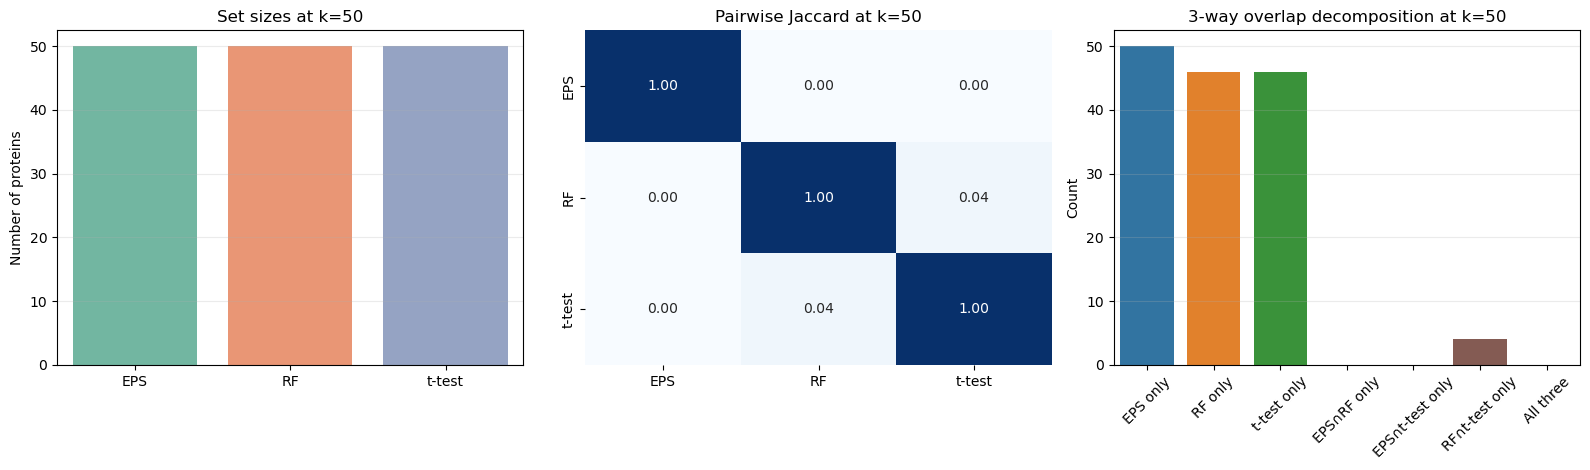

In [97]:
k0 = 50   # change this to any common k
size_df, pair_df, region_df = overlap_report(k0)

# Pairwise jaccard heatmap matrix
S = sets_at_k(k0)
names = ["EPS", "RF", "t-test"]
jmat = pd.DataFrame(index=names, columns=names, dtype=float)
for i in names:
    for j in names:
        A, B = S[i], S[j]
        jmat.loc[i, j] = len(A & B) / len(A | B) if len(A | B) else np.nan

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.barplot(data=size_df, x="method", y="set_size", ax=axes[0], palette="Set2")
axes[0].set_title(f"Set sizes at k={k0}")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of proteins")
axes[0].grid(axis="y", alpha=0.25)

sns.heatmap(jmat, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title(f"Pairwise Jaccard at k={k0}")

sns.barplot(data=region_df, x="region", y="count", ax=axes[2], palette="tab10")
axes[2].set_title(f"3-way overlap decomposition at k={k0}")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

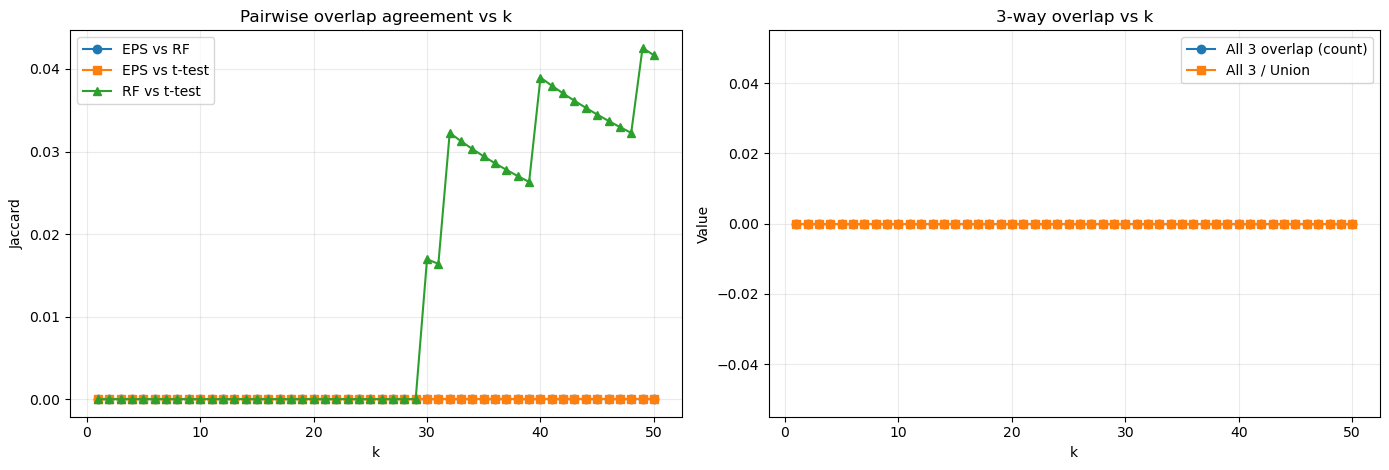

,k,Jaccard EPS-RF,Jaccard EPS-t-test,Jaccard RF-t-test,All3 count,All3/Union
0,1,0.0,0.0,0.000000,0,0.0
37,38,0.0,0.0,0.027027,0,0.0
27,28,0.0,0.0,0.000000,0,0.0
28,29,0.0,0.0,0.000000,0,0.0
29,30,0.0,0.0,0.016949,0,0.0
30,31,0.0,0.0,0.016393,0,0.0
31,32,0.0,0.0,0.032258,0,0.0
32,33,0.0,0.0,0.031250,0,0.0
33,34,0.0,0.0,0.030303,0,0.0
34,35,0.0,0.0,0.029412,0,0.0


In [98]:
trend_rows = []
for k in common_k:
    S = sets_at_k(k)
    E, R, T = S["EPS"], S["RF"], S["t-test"]

    er = len(E & R) / len(E | R) if len(E | R) else np.nan
    et = len(E & T) / len(E | T) if len(E | T) else np.nan
    rt = len(R & T) / len(R | T) if len(R | T) else np.nan

    all3 = len(E & R & T)
    union3 = len(E | R | T)
    all3_frac_union = all3 / union3 if union3 else np.nan

    trend_rows.append({
        "k": k,
        "Jaccard EPS-RF": er,
        "Jaccard EPS-t-test": et,
        "Jaccard RF-t-test": rt,
        "All3 count": all3,
        "All3/Union": all3_frac_union
    })

trend_df = pd.DataFrame(trend_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(trend_df["k"], trend_df["Jaccard EPS-RF"], marker="o", label="EPS vs RF")
axes[0].plot(trend_df["k"], trend_df["Jaccard EPS-t-test"], marker="s", label="EPS vs t-test")
axes[0].plot(trend_df["k"], trend_df["Jaccard RF-t-test"], marker="^", label="RF vs t-test")
axes[0].set_title("Pairwise overlap agreement vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Jaccard")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(trend_df["k"], trend_df["All3 count"], marker="o", label="All 3 overlap (count)")
axes[1].plot(trend_df["k"], trend_df["All3/Union"], marker="s", label="All 3 / Union")
axes[1].set_title("3-way overlap vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Value")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

# Compact numeric summary
display(trend_df.sort_values("All3 count", ascending=False).head(10))